# IMDB Movie Review Analysis

**Course:** CS178 - Machine Learning & Data Mining

**Team Members:** My Nguyen, Matthew Lee, Trinh Nguyen

## 1. Summary    

## 2. Data Description

### 2.1. Import and Setup

In [3]:
%pip install --upgrade pyarrow 
%pip install datasets
%pip install datasets-cli
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement datasets-cli (from versions: none)
ERROR: No matching distribution found for datasets-cli


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Classifiers - feel free to add what classifiers you want to use
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,        
    precision_score,        
    recall_score,            
    f1_score,              
    classification_report,   
    confusion_matrix,        
    ConfusionMatrixDisplay, 
    roc_auc_score,          
    roc_curve     
)

# Load the IMDB dataset
# install first: pip install datasets
from datasets import load_dataset

In [ ]:
seed = 1234
np.random.seed(seed) 

In [33]:
# Evaluation
dataset = load_dataset('imdb')
print(dataset)

# Unwrap list object
X_train_raw = list(dataset['train']['text'])
y_train_raw = list(dataset['train']['label'])

X_test_raw = list(dataset['test']['text'])
y_test_raw = list(dataset['test']['label'])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [35]:
info  = dataset['train'].info
features = []

for name, value in dataset['train'].features.items():
    features.append({'name': name, 'value': value})
    
feat_df = pd.DataFrame(features)
display(feat_df)

,name,value
0,text,Value('string')
1,label,"ClassLabel(names=['neg', 'pos'])"


In [37]:
X_train, X_val, y_train, y_val = train_test_split(X_train_raw, y_train_raw, test_size = 0.2, random_state=seed, stratify=y_train_raw)

In [47]:
vectorizer = TfidfVectorizer(   # can be tweaked so the 
    lowercase=True,
    stop_words='english',    
    max_features=25000,       
    ngram_range=(1, 2),       
    min_df=5,                  
    max_df=0.8,
    sublinear_tf=True  # applies (1 + log(tf))
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test_raw)

## 3. Classifiers:
### I. MLP Classifier

In [49]:
hidden_layers_options = [(128,), (64, 32)]
alpha_options = [0.0001, 0.01]
learning_rate_options = [0.001, 0.005]

best_acc = 0
best_params = {}
results_log = []

for layers in hidden_layers_options:
    for alpha_val in alpha_options:
        for lr in learning_rate_options:
            
            print(f"Training -> Layers: {layers} | Alpha: {alpha_val} | LR: {lr}")
            
            mlp = MLPClassifier(
                hidden_layer_sizes=layers,
                alpha=alpha_val,
                learning_rate_init=lr,
                solver='adam',  # faster than sgd for text data
                batch_size=256,
                max_iter=50,
                early_stopping=True,
                random_state=seed
            )
            

            mlp.fit(X_train_tfidf, y_train)
            
            y_pred = mlp.predict(X_val_tfidf)
            acc = accuracy_score(y_val, y_pred)
            
            print(f"Result -> Accuracy: {acc:.4f}\n")
            
            results_log.append({
                'Layers': str(layers), 
                'Alpha': alpha_val, 
                'Learning Rate': lr, 
                'Accuracy': acc
            })
            
            # Update best score if we found a new winner
            if acc > best_acc:
                best_acc = acc
                best_params = {'Layers': layers, 'Alpha': alpha_val, 'LR': lr}
                best_model = mlp 

Training -> Layers: (128,) | Alpha: 0.0001 | LR: 0.001
Result -> Accuracy: 0.8972

Training -> Layers: (128,) | Alpha: 0.0001 | LR: 0.005
Result -> Accuracy: 0.8950

Training -> Layers: (128,) | Alpha: 0.01 | LR: 0.001
Result -> Accuracy: 0.8978

Training -> Layers: (128,) | Alpha: 0.01 | LR: 0.005
Result -> Accuracy: 0.8964

Training -> Layers: (64, 32) | Alpha: 0.0001 | LR: 0.001
Result -> Accuracy: 0.9000

Training -> Layers: (64, 32) | Alpha: 0.0001 | LR: 0.005
Result -> Accuracy: 0.8938

Training -> Layers: (64, 32) | Alpha: 0.01 | LR: 0.001
Result -> Accuracy: 0.9014

Training -> Layers: (64, 32) | Alpha: 0.01 | LR: 0.005
Result -> Accuracy: 0.8916



In [51]:
print(best_acc)
print(best_params)

0.9014
{'Layers': (64, 32), 'Alpha': 0.01, 'LR': 0.001}


In [53]:
filename = 'mlp_model.sav'
pickle.dump(best_model, open(filename, 'wb'))

In [59]:
results_df = pd.DataFrame(results_log)
display(results_df)

,Layers,Alpha,Learning Rate,Accuracy
0,"(128,)",0.0001,0.001,0.8972
1,"(128,)",0.0001,0.005,0.8950
2,"(128,)",0.0100,0.001,0.8978
3,"(128,)",0.0100,0.005,0.8964
4,"(64, 32)",0.0001,0.001,0.9000
5,"(64, 32)",0.0001,0.005,0.8938
6,"(64, 32)",0.0100,0.001,0.9014
7,"(64, 32)",0.0100,0.005,0.8916


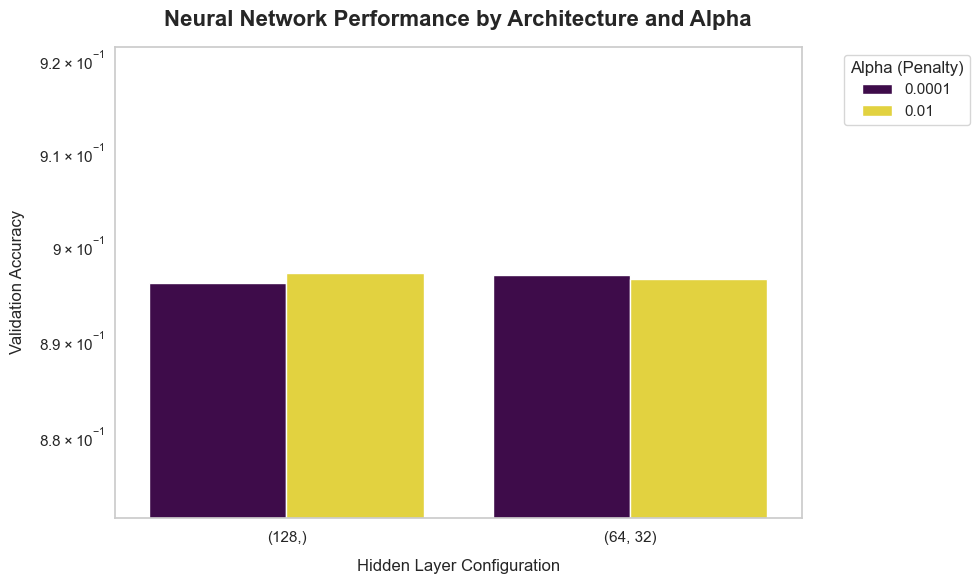

In [76]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df, 
    x='Layers', 
    y='Accuracy', 
    hue='Alpha', 
    palette='viridis',
    errorbar=None
)
min_acc = results_df['Accuracy'].min() - 0.02
max_acc = results_df['Accuracy'].max() + 0.02
plt.ylim(min_acc, max_acc)

plt.title("Neural Network Performance by Architecture and Alpha", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Hidden Layer Configuration", fontsize=12, labelpad=10)
plt.ylabel("Validation Accuracy", fontsize=12, labelpad=10)
plt.yscale('log')
plt.legend(title='Alpha (Penalty)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [73]:
# now predict on test data
y_te_pred = best_model.predict(X_test_tfidf)
acc_te = accuracy_score(y_test_raw, y_te_pred)
print(acc_te)

0.8848


#### Remarks: 
Turning `sublinear_tf` to True in the `TfidfVectorizer` has yielded higher training accuracy, which is most likely due to tf not being scaled linearly, making the number of term repetitions being less significant (non-linearly scaled).

In [78]:
cm_add = confusion_matrix(y_test_raw, y_te_pred)
cm_df_add = pd.DataFrame(cm_add, index=['true_neg', 'true_pos'], columns=['pred_neg', 'pred_pos'])
display(cm_df_add)

NameError: name 'y_test_add' is not defined

### II. Logistic Regression Analysis (Matthew Lee)

In [16]:
# Rebuild clean raw text splits from the dataset object so this section is independent
X_train_text_add = list(dataset['train']['text'])
y_train_add = np.array(dataset['train']['label'])
X_test_text_add = list(dataset['test']['text'])
y_test_add = np.array(dataset['test']['label'])

# Train/validation split from official train split (official test split remains untouched)
X_train_add, X_val_add, y_train_add_split, y_val_add = train_test_split(
    X_train_text_add,
    y_train_add,
    test_size=0.20,
    random_state=seed,
    stratify=y_train_add,
)

vectorizer_add = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=50_000,
)

X_train_add_tfidf = vectorizer_add.fit_transform(X_train_add)
X_val_add_tfidf = vectorizer_add.transform(X_val_add)

c_grid = [0.01, 0.1, 1.0, 10.0]
val_rows_add = []
best_c_add = None
best_f1_add = -1.0

for c_val in c_grid:
    model_add = LogisticRegression(
        C=c_val,
        solver='liblinear',
        max_iter=2000,
        random_state=seed,
    )
    model_add.fit(X_train_add_tfidf, y_train_add_split)
    y_val_pred_add = model_add.predict(X_val_add_tfidf)

    precision_add, recall_add, f1_add, _ = precision_recall_fscore_support(
        y_val_add,
        y_val_pred_add,
        average='binary',
        zero_division=0,
    )
    acc_add = accuracy_score(y_val_add, y_val_pred_add)

    val_rows_add.append({
        'C': c_val,
        'val_accuracy': acc_add,
        'val_precision': precision_add,
        'val_recall': recall_add,
        'val_f1': f1_add,
    })

    if f1_add > best_f1_add:
        best_f1_add = f1_add
        best_c_add = c_val

val_results_add = pd.DataFrame(val_rows_add).sort_values('val_f1', ascending=False).reset_index(drop=True)
display(val_results_add)
print(f"Best validation model: C={best_c_add}, F1={best_f1_add:.4f}")


,C,val_accuracy,val_precision,val_recall,val_f1
0,10.00,0.8948,0.888583,0.9028,0.895635
1,1.00,0.8888,0.877916,0.9032,0.890379
2,0.10,0.8542,0.833020,0.8860,0.858694
3,0.01,0.8094,0.791118,0.8408,0.815203


Best validation model: C=10.0, F1=0.8956


,accuracy,precision,recall,f1,selected_C
0,0.8814,0.888518,0.87224,0.880304,10.0


              precision    recall  f1-score   support

    negative     0.8745    0.8906    0.8825     12500
    positive     0.8885    0.8722    0.8803     12500

    accuracy                         0.8814     25000
   macro avg     0.8815    0.8814    0.8814     25000
weighted avg     0.8815    0.8814    0.8814     25000



,pred_neg,pred_pos
true_neg,11132,1368
true_pos,1597,10903


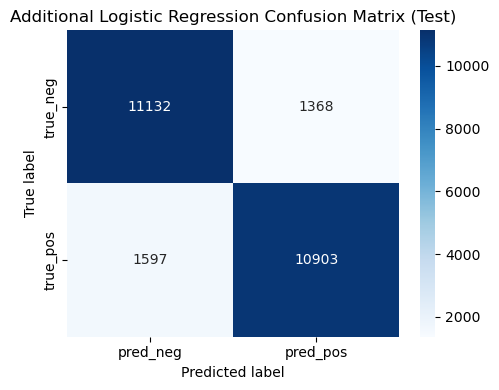

Saved: logistic_regression_imdb.pkl and tfidf_vectorizer_imdb.pkl


In [17]:
# Refit on train+validation with selected C, then evaluate once on official test split
X_trainval_add = X_train_add + X_val_add
y_trainval_add = np.concatenate([y_train_add_split, y_val_add])

vectorizer_final_add = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=50_000,
)

X_trainval_add_tfidf = vectorizer_final_add.fit_transform(X_trainval_add)
X_test_add_tfidf = vectorizer_final_add.transform(X_test_text_add)

final_model_add = LogisticRegression(
    C=best_c_add,
    solver='liblinear',
    max_iter=2000,
    random_state=seed,
)
final_model_add.fit(X_trainval_add_tfidf, y_trainval_add)

y_test_pred_add = final_model_add.predict(X_test_add_tfidf)

test_precision_add, test_recall_add, test_f1_add, _ = precision_recall_fscore_support(
    y_test_add,
    y_test_pred_add,
    average='binary',
    zero_division=0,
)
test_accuracy_add = accuracy_score(y_test_add, y_test_pred_add)

test_metrics_add = pd.DataFrame([
    {
        'accuracy': test_accuracy_add,
        'precision': test_precision_add,
        'recall': test_recall_add,
        'f1': test_f1_add,
        'selected_C': best_c_add,
    }
])

display(test_metrics_add)
print(classification_report(y_test_add, y_test_pred_add, target_names=['negative', 'positive'], digits=4))

cm_add = confusion_matrix(y_test_add, y_test_pred_add)
cm_df_add = pd.DataFrame(cm_add, index=['true_neg', 'true_pos'], columns=['pred_neg', 'pred_pos'])
display(cm_df_add)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df_add, annot=True, fmt='d', cmap='Blues')
plt.title('Additional Logistic Regression Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

with open('logistic_regression_imdb.pkl', 'wb') as f:
    pickle.dump(final_model_add, f)
with open('tfidf_vectorizer_imdb.pkl', 'wb') as f:
    pickle.dump(vectorizer_final_add, f)

print('Saved: logistic_regression_imdb.pkl and tfidf_vectorizer_imdb.pkl')


### 8.1 Additional Notes

- Validation tuning metric: F1 score.
- Final evaluation metric set: accuracy, precision, recall, F1, and confusion matrix.
